In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

In [29]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [30]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [31]:
model = tf.keras.Sequential([

    tf.keras.layers.Flatten(input_shape=(28,28)),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')

])

In [32]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9290 - loss: 0.2369 - val_accuracy: 0.9540 - val_loss: 0.1436
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9688 - loss: 0.1004 - val_accuracy: 0.9647 - val_loss: 0.1105
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9773 - loss: 0.0712 - val_accuracy: 0.9754 - val_loss: 0.0871
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9829 - loss: 0.0537 - val_accuracy: 0.9760 - val_loss: 0.0777
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9866 - loss: 0.0423 - val_accuracy: 0.9749 - val_loss: 0.0833
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9886 - loss: 0.0357 - val_accuracy: 0.9800 - val_loss: 0.0683
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9908 - loss: 0.0284 - val_accuracy: 0.9749 - val_loss: 0.0914
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9917 - loss: 0.0255 

In [34]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Accuracy =", accuracy*100,"%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0870
Accuracy = 97.87999987602234 %


In [35]:
model.save("mnist_model.h5")

In [36]:
uploaded = files.upload()

Saving 3-digit.PNG to 3-digit (2).PNG


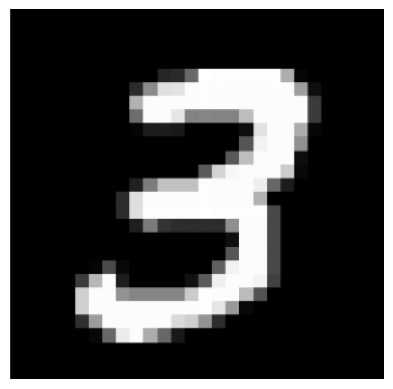

In [38]:
img = cv2.imread('3-digit.PNG',cv2.IMREAD_GRAYSCALE)

plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

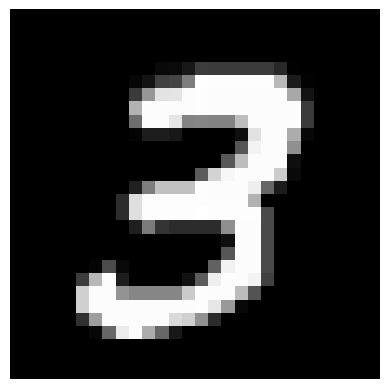

In [39]:
# resize

img = cv2.resize(img,(28,28))

# normalize

img = img.astype('float32') / 255.0

plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()

In [40]:
img_input = img.reshape(1,28,28)

prediction = model.predict(img_input)

digit = np.argmax(prediction)

print("Predicted Digit =",digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
Predicted Digit = 3


In [45]:
print("Probabilities:\n")

for i, p in enumerate(prediction[0]):
    print(f"{i} : {p*100:.10f}%")

Probabilities:

0 : 0.0000000000%
1 : 0.0000000001%
2 : 0.0000000000%
3 : 100.0000000000%
4 : 0.0000000000%
5 : 0.0000000002%
6 : 0.0000000000%
7 : 0.0000000000%
8 : 0.0000000000%
9 : 0.0000000171%


In [42]:
print(prediction)

[[4.70905548e-24 8.02021752e-13 1.88459803e-19 1.00000000e+00
  1.27635571e-19 1.58556219e-12 1.87230261e-33 1.26182574e-14
  1.59765796e-14 1.71355000e-10]]


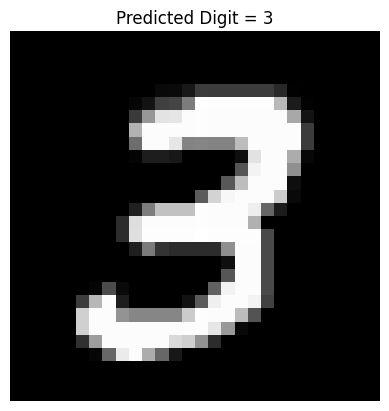

In [46]:
plt.imshow(img.reshape(28,28),cmap='gray')

plt.title(f"Predicted Digit = {digit}")

plt.axis('off')

plt.show()